In [63]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from arch import arch_model
from data_wrangling import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from black_scholes import *
import time
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

## Pulling data from various data files

In [2]:
# data_dxy = yf.download("DX-Y.NYB", start="2000-01-01", end="2024-01-01", threads=False)
# data_2yr = yf.download("^IRX", start="2000-01-01", end="2024-01-01", threads=False)
# data_10yr = yf.download("^TNX", start="2000-01-01", end="2024-01-01", threads=False)
# data_vix = yf.download("^VIX", start="2000-01-01", end="2024-01-01", threads=False)

data_dxy = pd.read_csv("data/data_dxy.csv", index_col=0).Close
data_dxy.index = pd.to_datetime(data_dxy.index)
data_2yr = pd.read_csv("data/data_2yr.csv", index_col=0).Close
data_10yr = pd.read_csv("data/data_10yr.csv", index_col=0).Close
data_vix = pd.read_csv("data/data_vix.csv", index_col=0).Close
data_vix.index = pd.to_datetime(data_vix.index)

data_2s10s = data_2yr - data_10yr
data_2s10s.index = pd.to_datetime(data_2s10s.index)

aapl_time_series = pd.read_hdf("data/all_tickers_time_series.hf5", key="AAPL").drop_duplicates().set_index("date")
aapl_returns = aapl_time_series.prc.pct_change()

In [3]:
print(len(aapl_time_series.index))
print(len(data_dxy.index))
print(len(data_2s10s.index))
print(len(data_vix.index))

6037
6064
6031
6037


Apparantly these dataframes have a difference in data lengths

In [4]:
dates_aapl = set(aapl_time_series.index)
dates_dxy = set(data_dxy.index)
dates_2s10s = set(data_2s10s.index)
dates_vix = set(data_vix.index)

common_dates = dates_aapl & dates_dxy & dates_2s10s & dates_vix
not_common_dates = (dates_aapl | dates_dxy | dates_2s10s | dates_vix) - common_dates

print(len(common_dates))
print(len(not_common_dates))

6030
36


In [5]:
sorted(list(not_common_dates))

[Timestamp('2000-01-17 00:00:00'),
 Timestamp('2000-02-21 00:00:00'),
 Timestamp('2000-07-04 00:00:00'),
 Timestamp('2000-11-23 00:00:00'),
 Timestamp('2001-01-15 00:00:00'),
 Timestamp('2001-02-19 00:00:00'),
 Timestamp('2001-07-04 00:00:00'),
 Timestamp('2001-09-03 00:00:00'),
 Timestamp('2001-11-22 00:00:00'),
 Timestamp('2002-01-21 00:00:00'),
 Timestamp('2002-02-18 00:00:00'),
 Timestamp('2002-05-27 00:00:00'),
 Timestamp('2002-07-04 00:00:00'),
 Timestamp('2002-11-28 00:00:00'),
 Timestamp('2003-07-04 00:00:00'),
 Timestamp('2003-09-01 00:00:00'),
 Timestamp('2003-11-11 00:00:00'),
 Timestamp('2004-01-19 00:00:00'),
 Timestamp('2004-02-16 00:00:00'),
 Timestamp('2004-06-11 00:00:00'),
 Timestamp('2004-07-05 00:00:00'),
 Timestamp('2004-09-06 00:00:00'),
 Timestamp('2004-11-25 00:00:00'),
 Timestamp('2004-12-24 00:00:00'),
 Timestamp('2005-01-17 00:00:00'),
 Timestamp('2005-02-21 00:00:00'),
 Timestamp('2005-07-04 00:00:00'),
 Timestamp('2005-10-10 00:00:00'),
 Timestamp('2005-11-

Turns out these dates are the days where it is a banking holiday, thus stock market not opened, but various indexes continues to count <br>
Note, 2016-10-10 and 2016-11-11 are banking holidays, but AAPL continued to trade

In [6]:
new_aapl = aapl_time_series[aapl_time_series.index.isin(common_dates)]
new_data_dxy = data_dxy[data_dxy.index.isin(common_dates)]
new_data_2s10s = data_2s10s[data_2s10s.index.isin(common_dates)]
new_data_vix = data_vix[data_vix.index.isin(common_dates)]

## EDA

In [7]:
adf_test(new_data_dxy)
print('---')
adf_test(new_data_2s10s)
print('---')
adf_test(new_data_vix)

ADF Statistic: -1.5625279264735055
p-value: 0.5023845733881521
Non-stationary: Consider differencing or other transformations
---
ADF Statistic: -1.4974466159694706
p-value: 0.5347740811956415
Non-stationary: Consider differencing or other transformations
---
ADF Statistic: -5.809785756316987
p-value: 4.429021238909754e-07
Stationary: No differencing required


4.429021238909754e-07

In [8]:
new_data_dxy_d1 = new_data_dxy.diff().dropna()
adf_test(new_data_dxy_d1)
print("---")
new_data_2s10s_d1 = new_data_2s10s.diff().dropna()
adf_test(new_data_2s10s_d1)

ADF Statistic: -23.419312260383563
p-value: 0.0
Stationary: No differencing required
---
ADF Statistic: -15.039411414105626
p-value: 9.642058296564496e-28
Stationary: No differencing required


9.642058296564496e-28

Datasets to be used: <br>
DXY: new_data_dxy_d1 <br>
2s10s: new_data_2s10s_d1 <br>
VIX: new_data_vix

## Testing DXY

In [9]:
goldfeld_quandt_test(new_aapl['prc'].pct_change().dropna(), new_data_dxy.pct_change().dropna())

{'F-statistic': 0.6113312480717363, 'p-value': 0.9999999999999999}

Based on GQ test, since p-value is close to 1, we do not reject H0, suggesting that homoscedasticity, meeting the assumption of constant variance

In [10]:
white_test(new_aapl['prc'].pct_change().dropna(), new_data_dxy.pct_change().dropna())

{'LM-statistic': 1.3307228729956266,
 'LM-test p-value': 0.514087684071219,
 'F-statistic': 0.6651771741276042,
 'F-test p-value': 0.5142201696270757}

Based on White's test, failed to reject H0 as both LM-statistic and F-statistics are both not significant. This suggests that variance of residual is homoscedastic

## Testing 2s10s

In [11]:
aapl_returns = new_aapl['prc'].pct_change().dropna()
dxy_returns = new_data_2s10s.pct_change().dropna()

merged_data = pd.merge(aapl_returns, dxy_returns, left_index=True, right_index=True, how='inner')

merged_data = merged_data.replace([np.inf, -np.inf], np.nan).dropna()

gq_test_results = goldfeld_quandt_test(merged_data.iloc[:, 0], merged_data.iloc[:, 1])
white_test_results = white_test(merged_data.iloc[:, 0], merged_data.iloc[:, 1])

print(gq_test_results)
print(white_test_results)

{'F-statistic': 3.4617351398397833, 'p-value': 4.929946278060511e-240}
{'LM-statistic': 0.2703809463549116, 'LM-test p-value': 0.8735495080903555, 'F-statistic': 0.13512925303093257, 'F-test p-value': 0.8736056361016313}


GQ test and White's test showing conflicting results (GQ suggesting heteroscedasticity while White's showing homoscedasticity). White's test generally considered stricter and more comprehensive as it makes few assumptions of form of heteroscedasticity, thus we will follow White's results

## Testing VIX

In [12]:
goldfeld_quandt_test(new_aapl['prc'].pct_change().dropna(), new_data_vix.pct_change().dropna())

{'F-statistic': 1.632306755824517, 'p-value': 3.974481603250593e-41}

In [13]:
white_test(new_aapl['prc'].pct_change().dropna(), new_data_vix.pct_change().dropna())

{'LM-statistic': 746.6320908035916,
 'LM-test p-value': 7.42850595868739e-163,
 'F-statistic': 425.87008861589266,
 'F-test p-value': 1.0084858502142215e-173}

Both GQ and White suggests presence of heteroscedasticity by rejecting null hypothesis of homoscedasticity.

## Regressing Exogenous Variables on Stock Price Returns

In [14]:
dxy_returns = new_data_dxy_d1.pct_change().dropna()
d_2s10s_returns = new_data_2s10s_d1.pct_change().dropna()
vix_returns = new_data_vix.pct_change().dropna()
# inf_dates = d_2s10s_returns[d_2s10s_returns==np.inf].index
# zero_dates = d_2s10s_returns[d_2s10s_returns==0].index
# print(f"dates with np.inf: {inf_dates}, dates with zeros: {zero_dates}")

Note that the inf comes from measuring a percentage change from a 0 value to a non-zero value, and 0 comes from measuring a percentage change from a non-zero value to a 0 value <br>
Perhaps, best way to move forward is to drop these dates

In [15]:
# X = sm.add_constant(pd.concat([dxy_returns, d_2s10s_returns, vix_returns], axis=1)).drop(inf_dates).drop(zero_dates)
# y = new_aapl['prc'].pct_change().dropna().drop(inf_dates).drop(zero_dates)

X_df = pd.concat([dxy_returns, d_2s10s_returns, vix_returns], axis=1)
comb_df = X_df.merge(new_aapl['prc'].pct_change(), left_index=True, right_index=True, how="inner")
comb_df.columns = ["DXY", "2s10s", "VIX", "returns"]
comb_df.replace([np.inf, -np.inf], np.nan, inplace=True)
comb_df.dropna(inplace=True)
comb_df

X = comb_df[["DXY", "2s10s", "VIX"]]
y = comb_df["returns"]
ols_model = sm.OLS(y, X).fit()
residuals = ols_model.resid

## Building the GARCH Model

$$
\sigma_t^2 = \alpha_0 + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2
$$

The above is the general form of GARCH(1,1) model

In [16]:
garch = arch_model(residuals, vol="Garch", p=1, q=1)
garch_fit = garch.fit()
garch_fit.summary()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 770230567.7775779
Iteration:      2,   Func. Count:     17,   Neg. LLF: -13071.45399295337
Optimization terminated successfully    (Exit mode 0)
            Current function value: -13071.453974124563
            Iterations: 6
            Function evaluations: 17
            Gradient evaluations: 2


c:\Users\Gavin\anaconda3\Lib\site-packages\arch\univariate\base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.00076. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                13071.5
Distribution:                  Normal   AIC:                          -26134.9
Method:            Maximum Likelihood   BIC:                          -26108.2
                                        No. Observations:                 5923
Date:                Thu, Oct 10 2024   Df Residuals:                     5922
Time:                        00:40:39   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         9.2735e-04  7.878e-04      1.177      0.239 [-6.167e-04,2.471e-03]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      7.6004e-05  5.013e-05      1.516      0.129 [-2.224e-05,1.742e-04]
alpha[1]       0.0500  3.909e-02      1.279      0.201   [-2.662e-02,  0.127]
beta[1]        0.8500  8.535e-02      9.959  2.311e-23      [  0.683,  1.017]
=============================================================================

Covariance estimator: robust
"""

In [17]:
vol_forecast = garch_fit.conditional_volatility

## Incorporating Exogenous Variables in GARCH Model

In [18]:
garch_x_model = arch_model(comb_df["returns"], vol="Garch", p=1, q=1, x=comb_df[["DXY", "2s10s", "VIX"]])
garch_x_fit = garch_x_model.fit()
garch_x_fit.summary()

c:\Users\Gavin\anaconda3\Lib\site-packages\arch\univariate\base.py:311: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0008707. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


Iteration:      1,   Func. Count:      6,   Neg. LLF: 164827800.8043421
Iteration:      2,   Func. Count:     18,   Neg. LLF: 32099.2587436947
Iteration:      3,   Func. Count:     30,   Neg. LLF: 981169651760.2346
Iteration:      4,   Func. Count:     44,   Neg. LLF: 3138941.714535622
Iteration:      5,   Func. Count:     57,   Neg. LLF: 33411380395.449257
Iteration:      6,   Func. Count:     69,   Neg. LLF: -12669.853446815352
Optimization terminated successfully    (Exit mode 0)
            Current function value: -12669.853430317416
            Iterations: 10
            Function evaluations: 69
            Gradient evaluations: 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                12669.9
Distribution:                  Normal   AIC:                          -25331.7
Method:            Maximum Likelihood   BIC:                          -25305.0
                                        No. Observations:                 5923
Date:                Thu, Oct 10 2024   Df Residuals:                     5922
Time:                        00:40:40   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         6.1878e-04  7.773e-04      0.796      0.426 [-9.047e-04,2.142e-03]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      8.7070e-05  7.096e-05      1.227      0.220 [-5.200e-05,2.261e-04]
alpha[1]       0.0500  3.346e-02      1.494      0.135   [-1.558e-02,  0.116]
beta[1]        0.8500  9.580e-02      8.873  7.122e-19      [  0.662,  1.038]
=============================================================================

Covariance estimator: robust
"""

## Forecasting

In [19]:
forecast_horizon = 5
forecast = garch_x_fit.forecast(horizon=forecast_horizon)
variance_forecast = forecast.variance[-1:]
variance_forecast.apply(np.sqrt)

,h.1,h.2,h.3,h.4,h.5
2023-12-29,0.024384,0.024944,0.025437,0.025873,0.026259


## OOP Portion

In [94]:
class DataProcessing:
    def __init__(self, y_variable_ticker: str):
        self.start_time = time.time()
        self.y_variable_ticker = y_variable_ticker
        self.data_dxy = pd.read_csv("data/data_dxy.csv", index_col=0).Close
        self.data_dxy.index = pd.to_datetime(self.data_dxy.index)

        self.data_2yr = pd.read_csv("data/data_2yr.csv", index_col=0).Close
        self.data_10yr = pd.read_csv("data/data_10yr.csv", index_col=0).Close
        self.data_2s10s = self.data_2yr - self.data_10yr
        self.data_2s10s.index = pd.to_datetime(self.data_2s10s.index)

        self.data_vix = pd.read_csv("data/data_vix.csv", index_col=0).Close
        self.data_vix.index = pd.to_datetime(self.data_vix.index)

        self.ticker_time_series = pd.read_hdf("data/all_tickers_time_series.hf5", key=y_variable_ticker).drop_duplicates().set_index("date")
        self.ticker_returns = self.ticker_time_series.prc.pct_change().dropna()

    def get_common_dates(self):
        dates_y = set(self.ticker_returns.index)
        dates_dxy = set(self.data_dxy.index)
        dates_2s10s = set(self.data_2s10s.index)
        dates_vix = set(self.data_vix.index)

        common_dates = dates_y & dates_dxy & dates_2s10s & dates_vix
        not_common_dates = (dates_y | dates_dxy | dates_2s10s | dates_vix) - common_dates

        return common_dates, not_common_dates
    
    def get_common_data(self):
        common_dates, _ = self.get_common_dates()

        new_y = self.ticker_returns[self.ticker_returns.index.isin(common_dates)]
        new_data_dxy = self.data_dxy[self.data_dxy.index.isin(common_dates)]
        new_data_2s10s = self.data_2s10s[self.data_2s10s.index.isin(common_dates)]
        new_data_vix = self.data_vix[self.data_vix.index.isin(common_dates)]

        return new_y, new_data_dxy, new_data_2s10s, new_data_vix
    
    def get_stationary_data(self):
        """
        Returns [y, dxy, 2s10s, vix] data that has been differenced until it is stationary
        """
        def difference_until_stationary(data):
            result = adf_test(data)
            differenced = 0

            while result > 0.05:
                data = data.diff().dropna()
                result = adf_test(data)
                differenced += 1

                if differenced > 2:
                    raise ValueError("Data could not be made stationary after 2 differences")
            return data, result
        
        stationary_results = []
        count = 0
        for data in self.get_common_data():
            try:
                count += 1
                if count == 1:
                    stationary_data = data
                else:
                    stationary_data, result = difference_until_stationary(data)
                stationary_results.append(stationary_data)
            except ValueError as e:
                print(f"Error with differencing for {data}: {e}")
        
        return stationary_results
    
    def data_split(self):
        y_stationary, dxy_stationary, d_2s10s_stationary, vix_stationary = self.get_stationary_data()
        X_df = pd.concat([dxy_stationary, d_2s10s_stationary, vix_stationary], axis=1)
        comb_df = X_df.merge(y_stationary, left_index=True, right_index=True, how="inner")
        comb_df.columns = ["DXY", "2s10s", "VIX", "returns"]
        comb_df.replace([np.inf, -np.inf], np.nan, inplace=True)
        comb_df.dropna(inplace=True)
        comb_df = comb_df.sort_index()
        X = comb_df[["DXY", "2s10s", "VIX"]]
        y = comb_df["returns"]
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))
        X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)
        y_scaled = pd.Series(y_scaled.flatten(), index=y.index)
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42, shuffle=False)
        X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42, shuffle=False)
        end_time = time.time()
        total_time = end_time - self.start_time
        print(f"Total time taken to split data for {self.y_variable_ticker}: {total_time} seconds")
        return X_train, X_test, y_train, y_test, X_val, y_val

class GARCHX:
    def __init__(self, y_variable_ticker: str, X_train, y_train, p=1, q=1, window_size=250):
        self.ticker = y_variable_ticker
        self.X_train = X_train
        self.y_train = y_train        
        self.p = p
        self.q = q
        self.window_size = window_size
        self.start_train_time = time.time()

    def train_get_GARCHX_fit(self):
        """
        Appropriate if exogenous variables have an impact on the volatility of the return and the returns itself.

        Exogeneous variables are included in the volatility equation, allowing them to influence variance of returns.
        """    
        garch_x_model = arch_model(self.y_train, vol="Garch", p=self.p, q=self.q, x=self.X_train, dist="t")
        self.garch_x_fit = garch_x_model.fit(disp="off")
        end_train_time = time.time()
        total_train_time = end_train_time - self.start_train_time
        print(f"Total time taken to train GARCHX for {self.ticker}: {total_train_time} seconds")
    
    def train_GARCHX_fit_summary(self):
        return self.garch_x_fit.summary()
    

    # def get_rolling_predictions(self, X_test, y_test): # time consuming
    #     self.X_test = X_test
    #     self.y_test = y_test
    #     start_pred_time = time.time()
    #     self.rolling_prediction = []
    #     rolling_y_train = self.y_train
    #     rolling_x_train = self.X_train
    #     for i in range(len(self.y_test)):
    #         rolling_y_train = pd.concat([self.y_train, self.y_test[:i+1]])
    #         rolling_x_train = pd.concat([self.X_train, self.X_test[:i+1]])
    #         garch_x_model = arch_model(rolling_y_train, vol="Garch", p=self.p, q=self.q, x=rolling_x_train, dist="t")
    #         garch_x_fit = garch_x_model.fit(disp="off")
    #         forecast = garch_x_fit.forecast(horizon=1)
    #         forecast_variance = forecast.variance.values[-1]
    #         self.rolling_prediction.append(forecast_variance)
        
    #     end_pred_time = time.time()
    #     total_time = end_pred_time - start_pred_time
    #     print(f"Total time taken to get rolling predictions for {self.ticker}: {total_time} seconds")

    def get_rolling_predictions(self, X_test, y_test):  # Time consuming
        self.X_test = X_test
        self.y_test = y_test
        start_pred_time = time.time()

        rolling_y_train = self.y_train
        rolling_x_train = self.X_train
        self.rolling_prediction = []
        def process_iteration(i):
            # Use a rolling window size of the last 'window_size' observations
            if len(rolling_y_train) > self.window_size:
                rolling_y_train_subset = rolling_y_train[-self.window_size:]
                rolling_x_train_subset = rolling_x_train[-self.window_size:]
            else:
                rolling_y_train_subset = rolling_y_train
                rolling_x_train_subset = rolling_x_train
            
            rolling_y_train_subset = pd.concat([rolling_y_train_subset, self.y_test[:i+1]])
            rolling_x_train_subset = pd.concat([rolling_x_train_subset, self.X_test[:i+1]])

            garch_x_model = arch_model(rolling_y_train_subset, vol="Garch", p=self.p, q=self.q, x=rolling_x_train_subset, dist="t")
            garch_x_fit= garch_x_model.fit(disp="off")
            # self.train_get_GARCHX_fit(rolling_y_train_subset, rolling_x_train_subset)
            forecast = garch_x_fit.forecast(horizon=1)
            forecast_variance = forecast.variance.values[-1]

            return forecast_variance

        self.rolling_prediction = Parallel(n_jobs=-1)(delayed(process_iteration)(i) for i in range(len(self.y_test)))

        end_pred_time = time.time()
        total_time = end_pred_time - start_pred_time
        print(f"Total time taken to get rolling predictions for {self.ticker}: {total_time} seconds")        

    def evaluate_rmse(self):
        squared_errors = (self.y_test**2).values - self.rolling_prediction
        rmse = np.sqrt(np.mean(squared_errors**2))
        return "RMSE (squared residuals vs predicted variance):", rmse
    
    def evaluate_smape(self):
        y_true = np.array(self.y_test)
        y_pred = np.array(self.rolling_prediction)

        numerator = np.abs(y_pred - y_true)
        denominator = (np.abs(y_true) + np.abs(y_pred))/2
        return "sMAPE :", np.mean(numerator/denominator) * 100

    def evaluate_directional_accuracy(self):
        realized_volatility = (self.y_test ** 2).values
        predicted_variance = np.array(self.rolling_prediction).flatten()

        realized_direction = np.sign(np.diff(realized_volatility))
        predicted_direction = np.sign(np.diff(predicted_variance))

        correct_directions = np.sum(realized_direction == predicted_direction)
        total_directions = len(realized_direction)

        directional_accuracy = correct_directions / total_directions
        directional_accuracy = directional_accuracy * 100
        return "Directional Accuracy:%", directional_accuracy


    def evaluate_hit_rate(self):
        realized_volatility = (self.y_test ** 2).values

        predicted_variance = np.array(self.rolling_prediction)

        high_threshold = np.percentile(realized_volatility, 75)
        low_threshold = np.percentile(realized_volatility, 25)

        realized_high = realized_volatility >= high_threshold
        predicted_high = predicted_variance >= high_threshold

        realized_low = realized_volatility <= low_threshold
        predicted_low = predicted_variance <= low_threshold
        high_hit_rate = np.mean(realized_high == predicted_high)
        low_hit_rate = np.mean(realized_low == predicted_low)

        return f"High Volatility Hit Rate: {high_hit_rate * 100:.2f}%, Low Volatility Hit Rate: {low_hit_rate * 100:.2f}%"
    
    def evaluate_qlike(self):
        realized_volatility = (self.y_test ** 2).values
        predicted_variance = np.array(self.rolling_prediction).flatten()
        qlike = np.mean(realized_volatility / predicted_variance - np.log(realized_volatility / predicted_variance) - 1)
        return "QLIKE:", qlike


class GARCHXModelPipeline:
    def __init__(self, tickers_list, p=1, q=1):
        self.tickers_list = tickers_list
        self.p = p
        self.q = q
        self.model_dict = {}

    def build_evaluate(self):
        for ticker in self.tickers_list:
            data_process = DataProcessing(ticker)
            X_train, X_test, y_train, y_test, X_val, y_val = data_process.data_split()
            garchx = GARCHX(ticker, X_train, y_train, self.p, self.q)
            garchx.train_get_GARCHX_fit()
            garchx.get_rolling_predictions(X_test, y_test)

            start_time = time.time()
            rmse = garchx.evaluate_rmse()
            smape = garchx.evaluate_smape()
            directional_accuracy = garchx.evaluate_directional_accuracy()
            qlike = garchx.evaluate_qlike()

            self.model_dict[ticker] = {
                "RMSE": rmse[1],
                "sMAPE": smape[1],
                "Directional Accuracy": directional_accuracy[1],
                "QLIKE": qlike[1],
                "Model": garchx.garch_x_fit,
                "Rolling Predictions": pd.Series([float(x[0]) for x in garchx.rolling_prediction], index=y_test.index)
            }
            end_time = time.time()
            total_time = end_time - start_time
            print(f"Total time taken to evaluate model for {ticker}: {total_time} seconds")
        return self.model_dict
    
    def get_model_dataframe(self):
        model_data = pd.DataFrame(self.model_dict).T.sort_values("sMAPE")
        return model_data
    
    def select_top_models(self, n):
        best_models = self.get_model_dataframe()
        selected_models = best_models.head(n)
        return selected_models

    
class VolatilityRiskPremia:
    def __init__(self, ticker_list):
        self.ticker_list = ticker_list
        self.pipeline = GARCHXModelPipeline(ticker_list)
        self.model_dict = self.pipeline.build_evaluate()
        self.selected_models = self.pipeline.select_top_models(5)
    
    def get_implied_volatility(self): # time consuming
        # tickers = self.selected_models["Ticker"].tolist()
        start_time = time.time()
        implied_volatility = {}
        for ticker in self.selected_models.index:
            price_data = pd.read_hdf("data/all_tickers_time_series.hf5", key=ticker).drop_duplicates().set_index("date")
            price_series = price_data["bidlo"] # subject to changes

            options_data = pd.read_hdf("data/all_options_data.h5", key=ticker).set_index("date")
            options_data['exdate'] = pd.to_datetime(options_data['exdate'])
            options_data.index = pd.to_datetime(options_data.index)

            options_data_filtered = options_data[options_data.index.isin(price_series.index)]
            options_data_filtered['price'] = price_series
            options_data_filtered["strike_minus_price"] = abs(options_data_filtered["strike_price"]/1000 - options_data_filtered["price"])

            date_index = options_data_filtered.index.unique()
            filtered_data = pd.DataFrame()
            for date in date_index:
                options_on_date = options_data_filtered.loc[date]
                no_of_ex_dates = options_on_date["exdate"].nunique()
                if no_of_ex_dates > 1:
                    options_on_date = options_on_date.query("exdate == exdate.min()")
                closest_strike = options_on_date[options_on_date["strike minus price"] == options_on_date["strike minus price"].min()]
                if len(closest_strike) > 2:
                    c_closest_strike = closest_strike[closest_strike["cp_flag"] == "C"]
                    c_closest_strike = c_closest_strike[c_closest_strike["open_interest"] == c_closest_strike["open_interest"].max()]
                    p_closest_strike = closest_strike[closest_strike["cp_flag"] == "P"]
                    p_closest_strike = p_closest_strike[p_closest_strike["open_interest"] == p_closest_strike["open_interest"].max()]        
                    closest_strike = pd.concat([c_closest_strike, p_closest_strike])        
                filtered_data = pd.concat([filtered_data, closest_strike])

            avg_implied_volatility = filtered_data.groupby("date").agg({"impl_volatility": "mean"})
            implied_volatility[ticker] = avg_implied_volatility
            end_time = time.time()
            total_time = end_time - start_time
            print(f"Implied Volatility time taken for: {ticker}, {total_time} seconds")
            # print(f"Implied Volatility index: {avg_implied_volatility.index}")
        return implied_volatility

    def get_backtest_rolling_forecast(self):
        """
        Where 
        Train data = training data + test data \n
        Test data = validation data
        """
        start_time = time.time()
        backtest_rolling_forecast = {}
        for ticker in self.selected_models.index:
            X_train, X_test, y_train, y_test, X_val, y_val = DataProcessing(ticker).data_split()

            garchx_for_trading = GARCHX(ticker,pd.concat([X_train, X_test]), pd.concat([y_train, y_test]))
            garchx_for_trading.train_get_GARCHX_fit()
            garchx_for_trading.get_rolling_predictions(X_val, y_val)
            roll_pred = pd.Series([pred.item() for pred in garchx_for_trading.rolling_prediction], index=y_val.index)
            roll_pred.name = "roll_pred"
            backtest_rolling_forecast[ticker] = roll_pred
            end_time = time.time()
            total_time = end_time - start_time
            print(f"Total time taken to get backtest rolling forecast for {ticker}: {total_time} seconds")
        return backtest_rolling_forecast
        

    def get_vrp_standardised(self): # time consuming
        start_time = time.time()
        implied_volatility = self.get_implied_volatility()
        backtest_rolling_forecast = self.get_backtest_rolling_forecast()
        vrp_standardised = {}
        for ticker in self.selected_models.index:
            # model = self.model_dict[ticker]["Model"]

            X_train, X_test, y_train, y_test, X_val, y_val = DataProcessing(ticker).data_split()

            iv = implied_volatility[ticker].copy()
            roll_pred = backtest_rolling_forecast[ticker].copy()
            vol_data = pd.merge(iv, roll_pred, left_index=True, right_index=True, how="inner")
            vol_data["vrp"] = vol_data["impl_volatility"] - vol_data["roll_pred"]
            vol_data["vrp_standardised"] = rolling_z_score(vol_data["vrp"], window=5).dropna()
            # data["rolling_pred"] = self.get_rolling_forecast(ticker, pd.concat([X_train, X_test]), pd.concat([y_train, y_test]), X_val, y_val)
            # data["vrp"] = data["impl_volatility"] - data["rolling_pred"]
            # data["vrp_standardised"] = rolling_z_score(data["vrp"], window=5)
            vrp_standardised[ticker] = vol_data["vrp_standardised"]
            end_time = time.time()
            total_time = end_time - start_time
            print(f"Total time taken to get VRP Standardised for {ticker}: {total_time} seconds")
        return vrp_standardised
    

# class GARCH:
#     def __init__(self, y_variable_ticker: str):
#         self.data_process = DataProcessing(y_variable_ticker)
#         self.X_train, self.X_test, self.y_train, self.y_test = self.data_process.data_split()

#     def train_get_OLS_residuals(self):
#         self.ols_model = sm.OLS(self.y_train, self.X_train).fit()
#         residuals = self.ols_model.resid
#         return residuals
    
#     def train_get_GARCH_fit(self, p=1, q=1):
#         """
#         More appropriate for for exogenous variables only affecting the mean (returns), 
#         and after accounting for them, model the volatility of the unexplained part of the returns.

#         Approach assumes volatility process itself is independent of the exogenous variables.
#         """
#         residuals = self.train_get_OLS_residuals()
#         garch = arch_model(residuals, vol="Garch", p=p, q=q)
#         self.garch_fit = garch.fit()

#     def train_GARCH_fit_summary(self):
#         return self.garch_fit.summary()
    
    
#     def test_get_GARCH_forecast_rmse(self, p=1, q=1):
#         test_residuals = self.y_test - self.ols_model.predict(self.X_test)
#         garch_forecast = self.garch_fit.forecast(horizon=len(self.y_test))
#         garch_vol_forecast = np.sqrt(garch_forecast.variance[-len(self.y_test):])
#         rmse = calculate_rmse(test_residuals, garch_vol_forecast.T)
#         return rmse

In [82]:
X_train, X_test, y_train, y_test, X_val, y_val = DataProcessing("AAPL").data_split()
garchx_for_trading = GARCHX("AAPL", pd.concat([X_train, X_test]), pd.concat([y_train, y_test]))
# garchx_for_trading = GARCHX("AAPL", X_train, y_train)
garchx_for_trading.train_get_GARCHX_fit()
garchx_for_trading.get_rolling_predictions(X_val, y_val)
roll_pred = garchx_for_trading.rolling_prediction

Total time taken to split data for AAPL: 0.9818964004516602 seconds
Total time taken to train GARCHX for AAPL: 0.061342716217041016 seconds
Total time taken to get rolling predictions for AAPL: 7.863873481750488 seconds


In [85]:
garchx_for_trading.evaluate_smape()

('sMAPE :', 1616.4889638321185)

In [84]:
new_roll_pred = pd.Series([pred.item() for pred in roll_pred], index=y_val.index)
new_roll_pred

Date
2020-05-28    0.156962
2020-05-29    0.142171
2020-06-01    0.142169
2020-06-02    0.125309
2020-06-03    0.111736
                ...   
2023-12-22    0.198352
2023-12-26    0.190948
2023-12-27    0.181559
2023-12-28    0.173103
2023-12-29    0.173796
Length: 905, dtype: float64

In [40]:
rolling_pred = pd.Series([pred.item() for pred in roll_pred], index=y_val.index)
rolling_pred.name = "rolling_pred"
rolling_pred

Date
2020-05-28    0.245232
2020-05-29    0.225344
2020-06-01    0.225686
2020-06-02    0.209130
2020-06-03    0.195886
                ...   
2023-12-22    0.185198
2023-12-26    0.177139
2023-12-27    0.167483
2023-12-28    0.159050
2023-12-29    0.159010
Name: rolling_pred, Length: 905, dtype: float64

In [26]:
price_data = pd.read_hdf("data/all_tickers_time_series.hf5", key="AAPL").drop_duplicates().set_index("date")
price_series = price_data["prc"] # subject to changes

options_data = pd.read_hdf("data/all_options_data.h5", key="AAPL").set_index("date")
options_data['exdate'] = pd.to_datetime(options_data['exdate'])
options_data.index = pd.to_datetime(options_data.index)

options_data_filtered = options_data[options_data.index.isin(price_series.index)]
options_data_filtered['price'] = price_series
options_data_filtered["strike minus price"] = abs(options_data_filtered["strike_price"]/1000 - options_data_filtered["price"])

date_index = options_data_filtered.index.unique()
filtered_data = pd.DataFrame()
for date in date_index:
    options_on_date = options_data_filtered.loc[date]
    no_of_ex_dates = options_on_date["exdate"].nunique()
    if no_of_ex_dates > 1:
        options_on_date = options_on_date.query("exdate == exdate.min()")
    closest_strike = options_on_date[options_on_date["strike minus price"] == options_on_date["strike minus price"].min()]
    if len(closest_strike) > 2:
        c_closest_strike = closest_strike[closest_strike["cp_flag"] == "C"]
        c_closest_strike = c_closest_strike[c_closest_strike["open_interest"] == c_closest_strike["open_interest"].max()]
        p_closest_strike = closest_strike[closest_strike["cp_flag"] == "P"]
        p_closest_strike = p_closest_strike[p_closest_strike["open_interest"] == p_closest_strike["open_interest"].max()]        
        closest_strike = pd.concat([c_closest_strike, p_closest_strike])        
    filtered_data = pd.concat([filtered_data, closest_strike])

avg_implied_volatility = filtered_data.groupby("date").agg({"impl_volatility": "mean"})
avg_implied_volatility

,impl_volatility
date,
2000-01-10,0.904786
2000-01-11,0.926436
2000-01-12,1.010805
2000-01-13,0.962808
2000-01-14,0.760772
...,...
2023-08-25,NaN
2023-08-28,0.218940
2023-08-29,0.233203


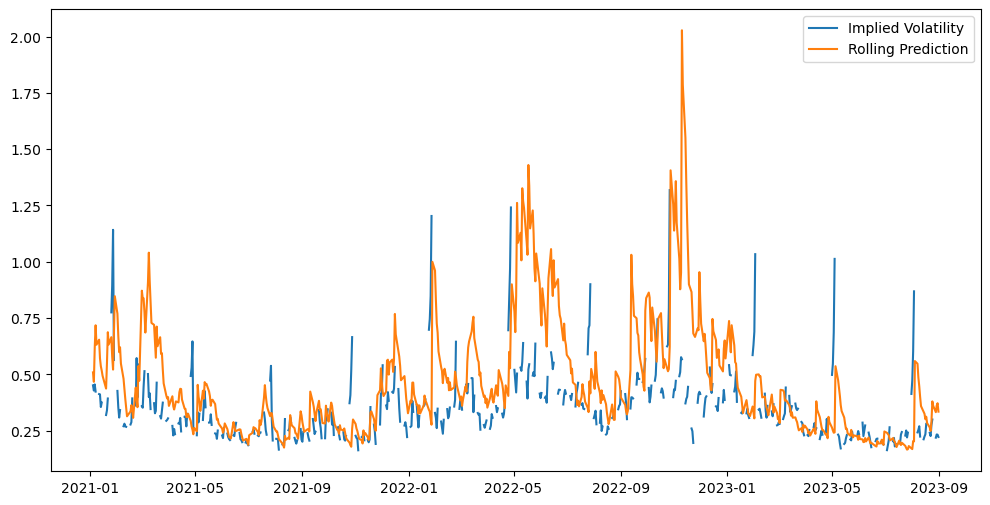

In [61]:
vrp = pd.merge(avg_implied_volatility, rolling_pred, left_index=True, right_index=True, how="inner")
vrp_standard = rolling_z_score(vrp["impl_volatility"] - vrp["rolling_pred"], window=5)
# vrp_standard.plot(figsize=(12, 6))
fig, ax = plt.subplots(figsize=(12, 6))
plt.plot(vrp["impl_volatility"]["2021":], label="Implied Volatility")
plt.plot(vrp["rolling_pred"]["2021":], label="Rolling Prediction")
plt.legend()

In [95]:
ticker_list = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
# ticker_list = ["AAPL"]

trading_strategy = VolatilityRiskPremia(ticker_list)
vrp_standardised = trading_strategy.get_vrp_standardised()

Total time taken to split data for AAPL: 1.504688024520874 seconds
Total time taken to train GARCHX for AAPL: 0.08277773857116699 seconds
Total time taken to get rolling predictions for AAPL: 12.707213640213013 seconds
Total time taken to evaluate model for AAPL: 0.022939443588256836 seconds
Total time taken to split data for MSFT: 1.1282567977905273 seconds
Total time taken to train GARCHX for MSFT: 0.04887032508850098 seconds
Total time taken to get rolling predictions for MSFT: 9.310692548751831 seconds
Total time taken to evaluate model for MSFT: 0.021943092346191406 seconds
Total time taken to split data for GOOGL: 0.9258208274841309 seconds
Total time taken to train GARCHX for GOOGL: 0.06585359573364258 seconds
Total time taken to get rolling predictions for GOOGL: 6.606646776199341 seconds
Total time taken to evaluate model for GOOGL: 0.017976045608520508 seconds
Total time taken to split data for AMZN: 2.0670642852783203 seconds
Total time taken to train GARCHX for AMZN: 0.0653

In [96]:
trading_strategy.selected_models

,RMSE,sMAPE,Directional Accuracy,QLIKE,Model,Rolling Predictions
GOOGL,1.694531,139.167151,70.781893,1.478998,Constant Mean - GARCH ...,2018-03-13 0.576604 2018-03-14 0.556742 ...
MSFT,3.505543,140.746873,72.203765,1.445257,Constant Mean - GARCH ...,Date 2016-10-20 0.255147 2016-10-21 0.73...
AMZN,0.911418,141.208571,73.643411,1.305882,Constant Mean - GARCH ...,Date 2016-10-20 0.115667 2016-10-21 0.11...
AAPL,1.461062,142.363717,73.643411,1.370188,Constant Mean - GARCH ...,Date 2016-10-20 0.127791 2016-10-21 0.12...
TSLA,17.217829,144.933928,75.787402,1.69822,Constant Mean - GARCH ...,2019-12-12 0.348144 2019-12-13 0.339524 ...


<Axes: >

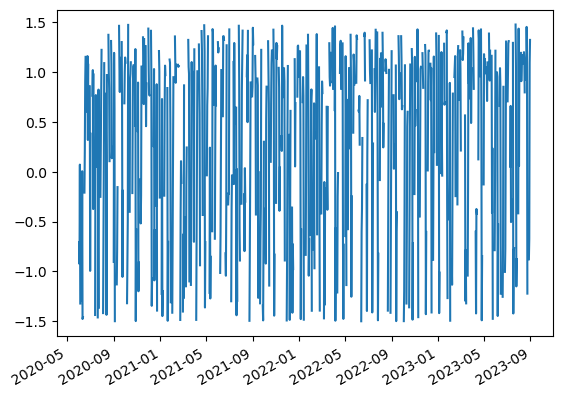

In [98]:
vrp_standardised["MSFT"].plot()

In [99]:
vrp_standardised["AAPL"].to_csv("data/AAPL_vrp_standardised.csv")

In [91]:
trading_strategy.selected_models

,RMSE,sMAPE,Directional Accuracy,QLIKE,Model,Rolling Predictions
AAPL,1.461062,-1132.192216,73.643411,1.370188,Constant Mean - GARCH ...,Date 2016-10-20 0.127791 2016-10-21 0.12...


<Axes: xlabel='date'>

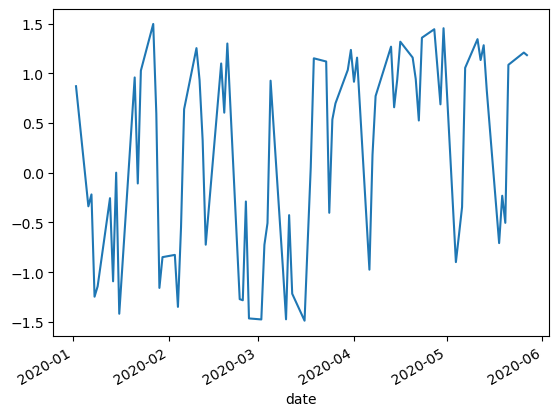

In [20]:
vrp_standardised["AAPL"].loc["2020"].plot()

In [282]:
tickers_df = pd.read_excel("data/RIY Index Constituents.xlsx")
unique_tickers = set()
cols = tickers_df.columns
for col in cols:
    tickers_for_year = tickers_df[col].unique()
    for ticker in tickers_for_year:
        unique_tickers.add(ticker.split()[0].strip().upper())

for ticker in unique_tickers:
    try:
        garchx = GARCHX(ticker)
        garchx.train_get_GARCHX_fit()
        garchx.get_rolling_predictions()
        print(f"{ticker}: {garchx.evaluate_rmse()}")
        print(f"{ticker}: {garchx.evaluate_directional_accuracy()}")
        print(f"{ticker}: {garchx.evaluate_hit_rate()}")
        print(f"{ticker}: {garchx.evaluate_qlike()}")
    except Exception as e:
        print(f"Error with {ticker}: {e}")

{'RYAN',
 'EXPE',
 'HUBB',
 'OXY',
 'TOL',
 'UNM',
 'PARA',
 'ALB',
 'SNX',
 'EXP',
 'SPOT',
 'JBL',
 'PR',
 'CDW',
 'HPQ',
 'NKE',
 'ADSK',
 'ALK',
 'CIVI',
 'BAC',
 'AMP',
 'FE',
 'SMG',
 'BLK',
 'GRAL',
 'RGLD',
 'CNA',
 'ILMN',
 'MGM',
 'KO',
 'MDB',
 'NTRA',
 'MOS',
 'AMH',
 'CMI',
 'SLGN',
 'TRU',
 'AON',
 'VSTS',
 'ETSY',
 'CERT',
 'GPK',
 'CRUS',
 'KDP',
 'LBRDA',
 'ETR',
 'MDLZ',
 'SJM',
 'HRB',
 'NNN',
 'PNR',
 'ZTS',
 'OZK',
 'NTAP',
 'NVST',
 'BOKF',
 'BDX',
 'CRWD',
 'TT',
 'PG',
 'DIS',
 'STT',
 'KMX',
 'WFRD',
 'CTAS',
 'AAON',
 'PPL',
 'CXT',
 'AXP',
 'UTHR',
 'INSP',
 'CRM',
 'RYN',
 'HEI',
 'HII',
 'EIX',
 'PTC',
 'EHC',
 'ARE',
 'FLO',
 'PPC',
 'CSX',
 'ACI',
 'OSK',
 'PK',
 'STAG',
 'WTM',
 'LOW',
 'COIN',
 'ANSS',
 'QS',
 'GILD',
 'TECH',
 'MMM',
 'HOLX',
 'TOST',
 'LLYVA',
 'LII',
 'BBY',
 'CSCO',
 'AMZN',
 'HLT',
 'USB',
 'J',
 'MP',
 'LVS',
 'PANW',
 'PINC',
 'SQ',
 'WPC',
 'EBAY',
 'HOOD',
 'KRC',
 'ROST',
 'TDY',
 'GLOB',
 'L',
 'UHAL',
 'COO',
 'VKTX',
 'WWD'

## Getting IV here <br>
But I note that there are some difficulties, eg which price to use given a case where there are 2 Calls/Puts with varying prices, with strike at same distance from spot price

In [478]:
price_data = pd.read_hdf("data/all_tickers_time_series.hf5", key="AAPL").drop_duplicates().set_index("date")
price_series = price_data["bidlo"]

options_data = pd.read_hdf("data/all_options_data.h5", key="AAPL").set_index("date")
options_data['exdate'] = pd.to_datetime(options_data['exdate'])
options_data.index = pd.to_datetime(options_data.index)

options_data_filtered = options_data[options_data.index.isin(price_series.index)]
options_data_filtered['price'] = price_series
options_data_filtered["strike minus price"] = abs(options_data_filtered["strike_price"]/1000 - options_data_filtered["price"])
options_data_filtered

date_index = options_data_filtered.index.unique()
filtered_data = pd.DataFrame()
for date in date_index:
    options_on_date = options_data_filtered.loc[date]
    no_of_ex_dates = options_on_date["exdate"].nunique()
    if no_of_ex_dates > 1:
        options_on_date = options_on_date.query("exdate == exdate.min()")
    closest_strike = options_on_date[options_on_date["strike minus price"] == options_on_date["strike minus price"].min()]
    if len(closest_strike) > 2:
        c_closest_strike = closest_strike[closest_strike["cp_flag"] == "C"]
        c_closest_strike = c_closest_strike[c_closest_strike["open_interest"] == c_closest_strike["open_interest"].max()]
        p_closest_strike = closest_strike[closest_strike["cp_flag"] == "P"]
        p_closest_strike = p_closest_strike[p_closest_strike["open_interest"] == p_closest_strike["open_interest"].max()]        
        closest_strike = pd.concat([c_closest_strike, p_closest_strike])        
    filtered_data = pd.concat([filtered_data, closest_strike])

filtered_data

,ticker,exdate,cp_flag,strike_price,best_bid,best_offer,open_interest,impl_volatility,delta,gamma,theta,vega,volume,price,strike minus price
date,,,,,,,,,,,,,,,
2000-01-10,AAPL,2000-01-22,C,95000.0,7.750,8.250,1178.0,0.924321,0.604557,0.023503,-98.85713,6.826139,402.0,94.75000,0.25000
2000-01-10,AAPL,2000-01-22,P,95000.0,4.750,4.875,2269.0,0.885251,-0.394524,0.024588,-89.57795,6.820148,229.0,94.75000,0.25000
2000-01-11,AAPL,2000-01-22,C,90000.0,7.500,7.625,2602.0,0.949785,0.608466,0.025109,-100.22590,6.184327,446.0,90.50000,0.50000
2000-01-11,AAPL,2000-01-22,P,90000.0,4.250,4.500,6949.0,0.903087,-0.389988,0.026440,-90.42674,6.176464,288.0,90.50000,0.50000
2000-01-12,AAPL,2000-01-22,P,85000.0,4.375,4.625,2727.0,0.983066,-0.403095,0.027336,-98.14248,5.585017,182.0,86.50000,1.50000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-29,AAPL,2023-09-01,P,180000.0,0.230,0.240,12263.0,0.223380,-0.125822,0.055538,-45.80185,3.450228,49053.0,179.50000,0.50000
2023-08-30,AAPL,2023-09-01,C,185000.0,3.050,3.150,36632.0,0.243143,0.792219,0.084788,-95.54815,3.975623,85304.0,184.74001,0.25999
2023-08-30,AAPL,2023-09-01,P,185000.0,0.310,0.320,13062.0,0.221147,-0.186169,0.087342,-73.43875,3.724309,72835.0,184.74001,0.25999
